In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 

In [2]:
notebook_path = Path.cwd()
base_path = notebook_path.parent

raw_path = base_path / "data" / "raw" 
plot_path = base_path / "fig"

In [3]:
toc=pd.read_csv(raw_path / "toc.csv", sep = ";")

In [4]:
# Step 2: Calculate organic matter lost (this is second step)
toc["organic_matter"] = toc["dry_weight"] - toc["ash_weight"]
toc["toc_percent"] = (toc["organic_matter"] / toc["dry_weight"]) * 100 * 0.58

In [5]:
# Group by site to get mean and standard deviation

mean_series_per_site = toc.groupby(['site', 'month', 'sample'])['toc_percent'].agg(['mean', 'std']).reset_index()
mean_series = toc.groupby(['month', 'sample'])['toc_percent'].agg(['mean', 'std']).reset_index()

total_series_per_site = toc.groupby(['site', 'month', 'sample'])['toc_percent'].agg(['sum']).reset_index()
total_series = toc.groupby(['month', 'sample'])['toc_percent'].agg(['sum']).reset_index()

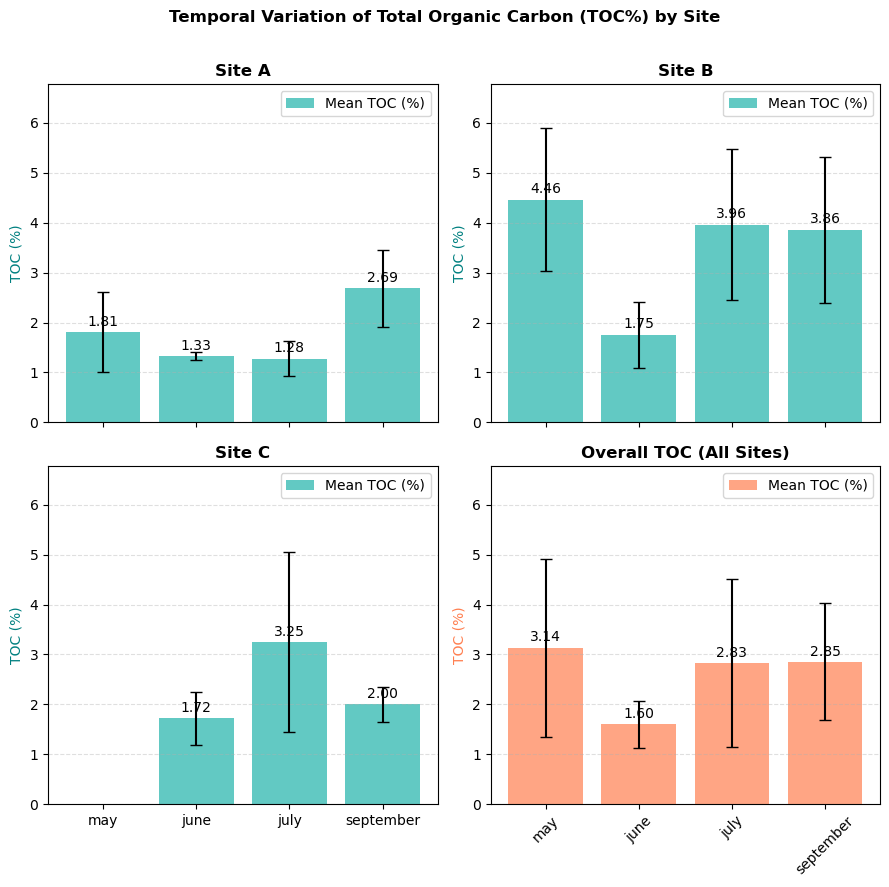

In [6]:

# --- Order months chronologically ---
month_order = ['may', 'june', 'july', 'september']
mean_series_per_site['month'] = pd.Categorical(
    mean_series_per_site['month'], categories=month_order, ordered=True
)
mean_series['month'] = pd.Categorical(
    mean_series['month'], categories=month_order, ordered=True
)

mean_series_per_site = mean_series_per_site.sort_values(['site', 'month'])
mean_series = mean_series.sort_values(['month'])

# --- Define sites and create subplots ---
sites = ['A', 'B', 'C']
fig, axes = plt.subplots(2, 2, figsize=(9, 9), sharex=True)
axes = axes.flatten()

# --- Compute global y-axis limits (including overall data) ---
y_min = 0
y_max = max(
    (mean_series_per_site['mean'] + mean_series_per_site['std'].fillna(0)).max(),
    (mean_series['mean'] + mean_series['std'].fillna(0)).max()
) * 1.15  # 15% buffer for labels

# --- Function to add labels above bars ---
def add_value_labels(ax, fmt="{:.2f}"):
    """Add numerical labels above bars."""
    for rect in ax.patches:
        height = rect.get_height()
        if height > 0:
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                height + (y_max * 0.01),
                fmt.format(height),
                ha='center', va='bottom',
                color='black'
            )

# --- Plot each site ---
for i, site in enumerate(sites):
    site_data = mean_series_per_site[mean_series_per_site['site'] == site]
    ax = axes[i]
    
    ax.bar(site_data['month'], site_data['mean'], yerr=site_data['std'],
           capsize=4, color='lightseagreen', alpha=0.7, label='Mean TOC (%)')
    
    ax.set_ylim(y_min, y_max)
    ax.set_title(f"Site {site}", weight='bold')
    ax.set_ylabel('TOC (%)', color='teal')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend()
    
    add_value_labels(ax)

# --- Overall subplot ---
ax = axes[3]
ax.bar(mean_series['month'], mean_series['mean'], yerr=mean_series['std'],
       capsize=4, color='coral', alpha=0.7, label='Mean TOC (%)')

ax.set_ylim(y_min, y_max)
ax.set_title('Overall TOC (All Sites)', weight='bold')
ax.set_ylabel('TOC (%)', color='coral')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend()
add_value_labels(ax)

# --- Global formatting ---
fig.suptitle('Temporal Variation of Total Organic Carbon (TOC%) by Site', weight='bold')
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(plot_path / "toc_mean_series_labeled.png", dpi=500)
plt.show()

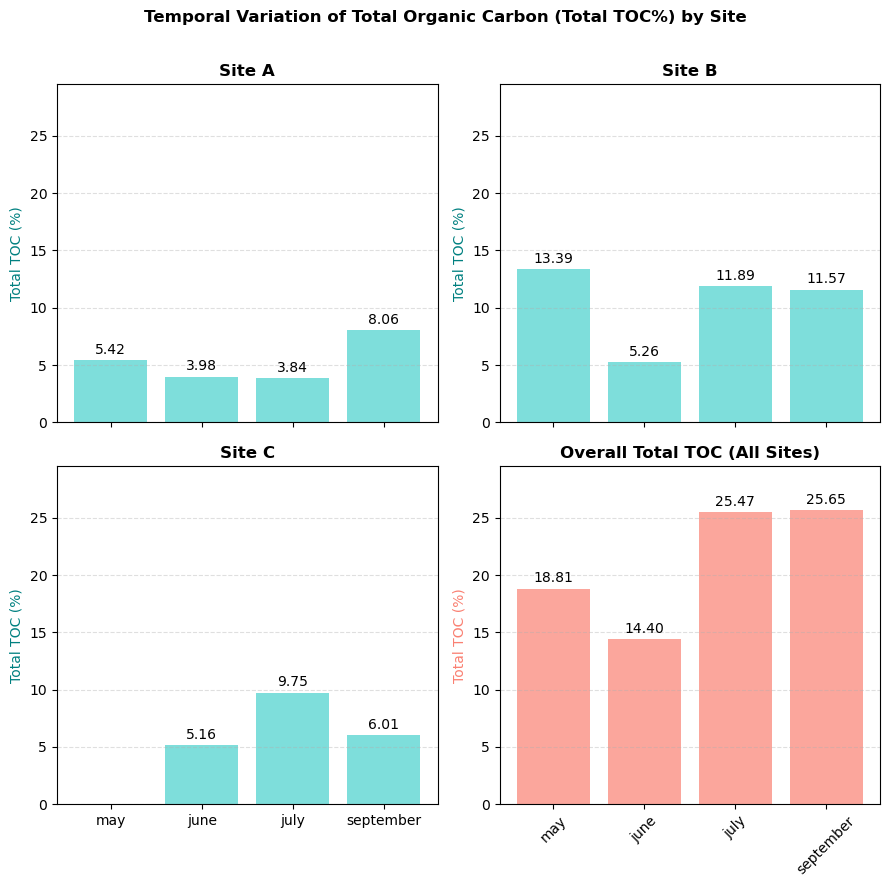

In [7]:
# --- Order months chronologically ---
month_order = ['may', 'june', 'july', 'september']
total_series_per_site['month'] = pd.Categorical(
    total_series_per_site['month'], categories=month_order, ordered=True
)
total_series['month'] = pd.Categorical(
    total_series['month'], categories=month_order, ordered=True
)

total_series_per_site = total_series_per_site.sort_values(['site', 'month'])
total_series = total_series.sort_values(['month'])

# --- Define sites and create subplots ---
sites = ['A', 'B', 'C']
fig, axes = plt.subplots(2, 2, figsize=(9, 9), sharex=True)
axes = axes.flatten()

# --- Compute global y-axis limits (including overall totals) ---
y_min = 0
y_max = max(
    total_series_per_site['sum'].max(),
    total_series['sum'].max()
) * 1.15  # 15% buffer for labels

# --- Function to add labels above bars ---
def add_value_labels(ax, spacing=3, fmt="{:.2f}"):
    """Add labels on top of bars."""
    for rect in ax.patches:
        height = rect.get_height()
        if height > 0:
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                height + (y_max * 0.01),
                fmt.format(height),
                ha='center', va='bottom',
                color='black'
            )

# --- Plot each site ---
for i, site in enumerate(sites):
    site_data = total_series_per_site[total_series_per_site['site'] == site]
    ax = axes[i]
    
    bars = ax.bar(site_data['month'], site_data['sum'],
                  color='mediumturquoise', alpha=0.7, label='Total TOC (%)')
    
    ax.set_ylim(y_min, y_max)
    ax.set_title(f"Site {site}", weight='bold')
    ax.set_ylabel('Total TOC (%)', color='teal')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    add_value_labels(ax)

# --- Overall subplot ---
ax = axes[3]
bars = ax.bar(total_series['month'], total_series['sum'],
              color='salmon', alpha=0.7, label='Total TOC (%)')

ax.set_ylim(y_min, y_max)
ax.set_title('Overall Total TOC (All Sites)', weight='bold')
ax.set_ylabel('Total TOC (%)', color='salmon')
ax.grid(axis='y', linestyle='--', alpha=0.4)
add_value_labels(ax)

# --- Global formatting ---
fig.suptitle('Temporal Variation of Total Organic Carbon (Total TOC%) by Site', weight='bold')
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(plot_path / "toc_total_series_scaled.png", dpi=500)
plt.show()